In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

In [4]:
print("Please upload 'Chocolate Sales.csv' below:")
uploaded = files.upload()

Please upload 'Chocolate Sales.csv' below:


Saving Dataset Sales.csv to Dataset Sales.csv


In [5]:
# 2. LOAD AND DOUBLE DATASET
filename = list(uploaded.keys())[0]
df_original = pd.read_csv(filename)

In [6]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [7]:
# Doubling the dataset for better results
df = pd.concat([df_original, df_original], ignore_index=True)
print(f"Dataset expanded from {len(df_original)} to {len(df)} rows.")

Dataset expanded from 1094 to 2188 rows.


In [8]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [9]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
2183,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
2184,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
2185,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
2186,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384
2187,Karlen McCaffrey,India,70% Dark Bites,23-May-22,"$5,075",344


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   2188 non-null   object
 1   Country        2188 non-null   object
 2   Product        2188 non-null   object
 3   Date           2188 non-null   object
 4   Amount         2188 non-null   object
 5   Boxes Shipped  2188 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 102.7+ KB


In [11]:
# 3. DATA CLEANING
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
df['Month'] = df['Date'].dt.month

In [13]:
# 2. DATA CLEANING & PREPROCESSING
# Safety check for 'Amount' formatting to prevent AttributeError
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].astype(str).str.replace('$', '').str.replace(',', '')
    df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
    df = df.dropna(subset=['Amount'])

# Date Features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df = df.dropna(subset=['Date'])

# Encoding categorical variables
le = LabelEncoder()
for col in ['Sales Person', 'Country', 'Product']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

In [14]:
# 3. FEATURE SELECTION
features = ['Sales Person', 'Country', 'Product', 'Boxes Shipped', 'Month', 'Quarter']
X = df[features]
y = df['Amount']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Crucial for KNN performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# 4. MODEL 1: K-NEAREST NEIGHBORS (KNN)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

# 5. MODEL 2: DECISION TREE REGRESSOR
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

In [16]:
# 6. PERFORMANCE CALCULATION
results = []
for name, pred in [("K-Nearest Neighbors", knn_pred), ("Decision Tree", dt_pred)]:
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2
    })
    print(f"--- {name} Results ---")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

results_df = pd.DataFrame(results)

--- K-Nearest Neighbors Results ---
Mean Squared Error: 18718542.31
Mean Absolute Error: 3471.50
R2 Score: -0.1494

--- Decision Tree Results ---
Mean Squared Error: 8342253.80
Mean Absolute Error: 1011.16
R2 Score: 0.4877



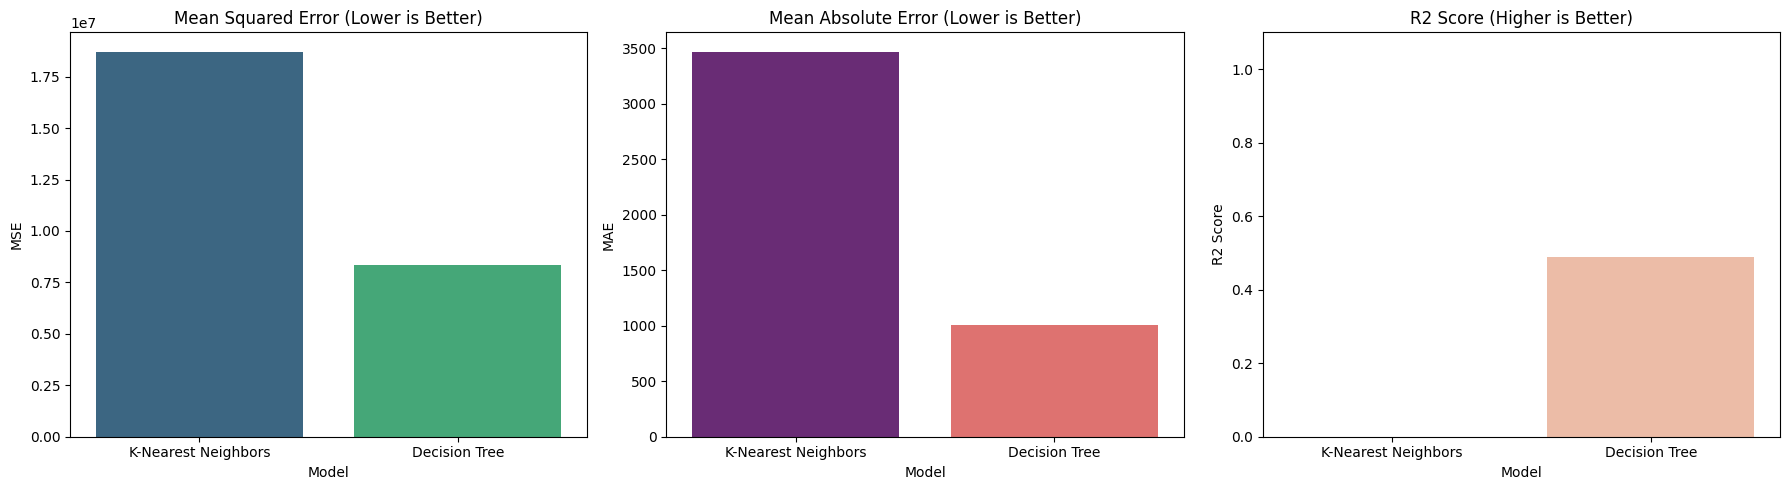

In [17]:
# 7. VISUALIZATION COMPARISON FOR ALL VALUES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MSE Comparison
sns.barplot(x='Model', y='MSE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Squared Error (Lower is Better)')

# MAE Comparison
sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Absolute Error (Lower is Better)')

# R2 Comparison
sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[2], palette='coolwarm')
axes[2].set_title('R2 Score (Higher is Better)')
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [18]:
# 5. DEFINE EVALUATION FUNCTION
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

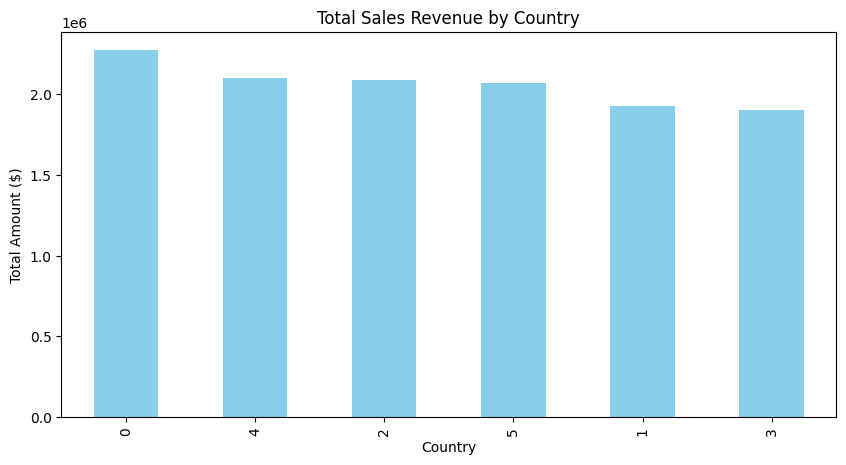

In [20]:
plt.figure(figsize=(10, 5))
df.groupby('Country')['Amount'].sum().sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Total Sales Revenue by Country')
plt.ylabel('Total Amount ($)')
plt.show()

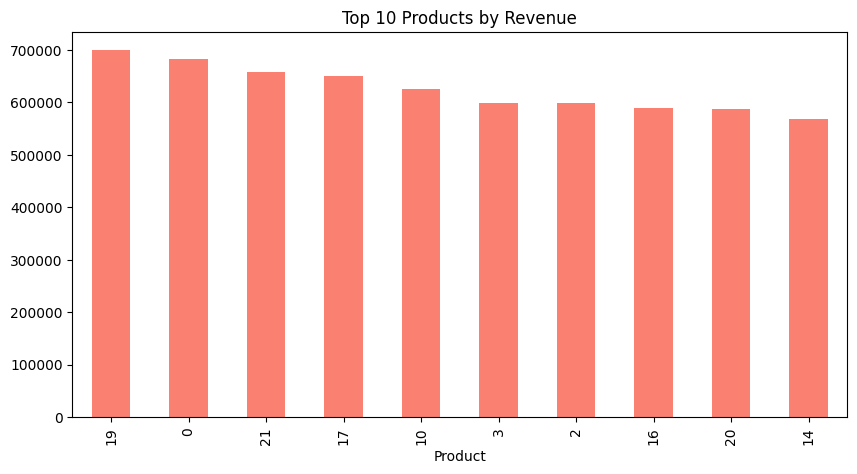

In [21]:
plt.figure(figsize=(10, 5))
df.groupby('Product')['Amount'].sum().nlargest(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Products by Revenue')
plt.show()

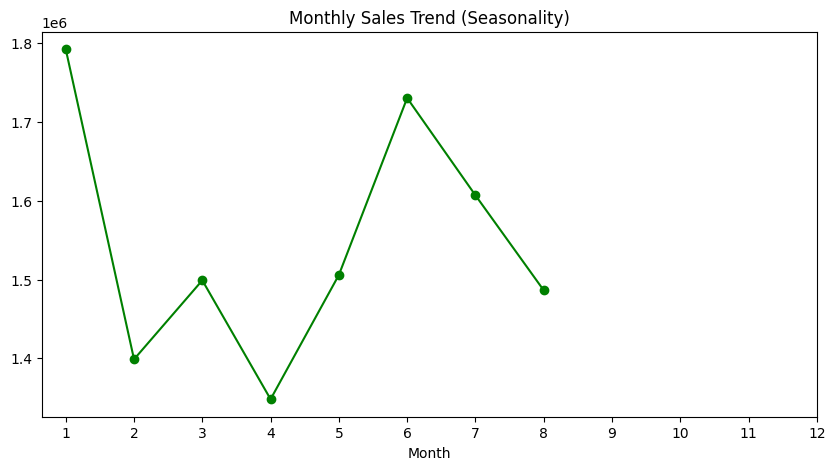

In [22]:
plt.figure(figsize=(10, 5))
df.groupby('Month')['Amount'].sum().plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend (Seasonality)')
plt.xticks(range(1, 13))
plt.show()

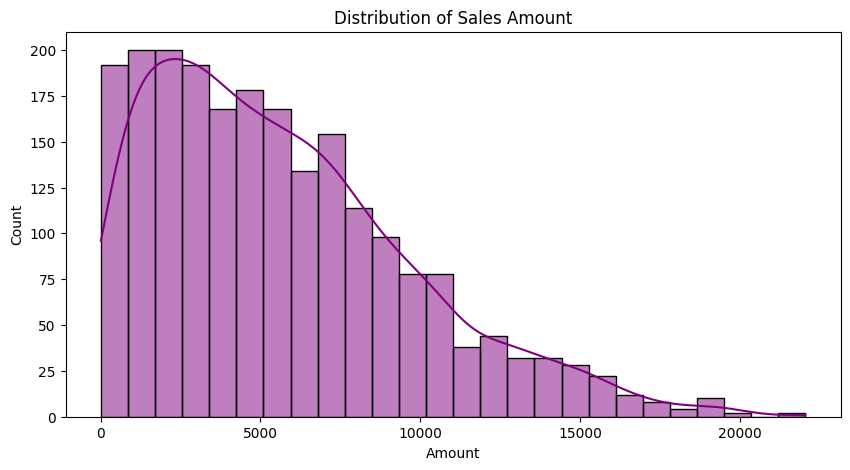

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], kde=True, color='purple')
plt.title('Distribution of Sales Amount')
plt.show()

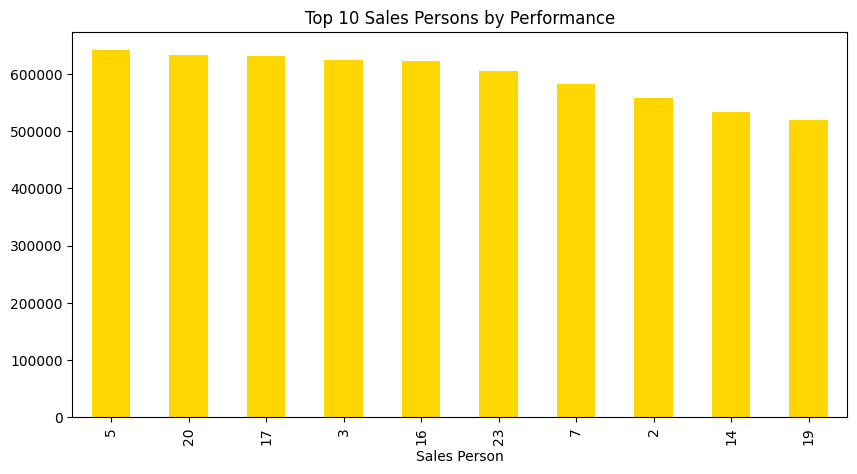

In [24]:
plt.figure(figsize=(10, 5))
df.groupby('Sales Person')['Amount'].sum().nlargest(10).plot(kind='bar', color='gold')
plt.title('Top 10 Sales Persons by Performance')
plt.show()

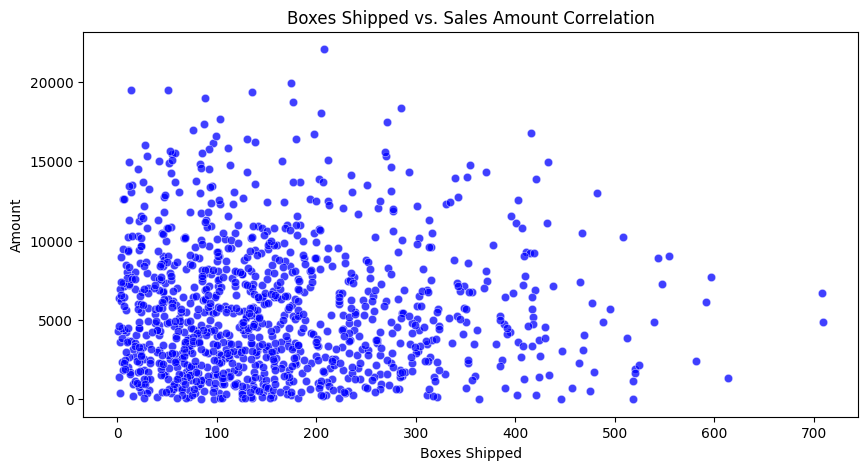

In [25]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Boxes Shipped', y='Amount', data=df, alpha=0.5, color='blue')
plt.title('Boxes Shipped vs. Sales Amount Correlation')
plt.show()

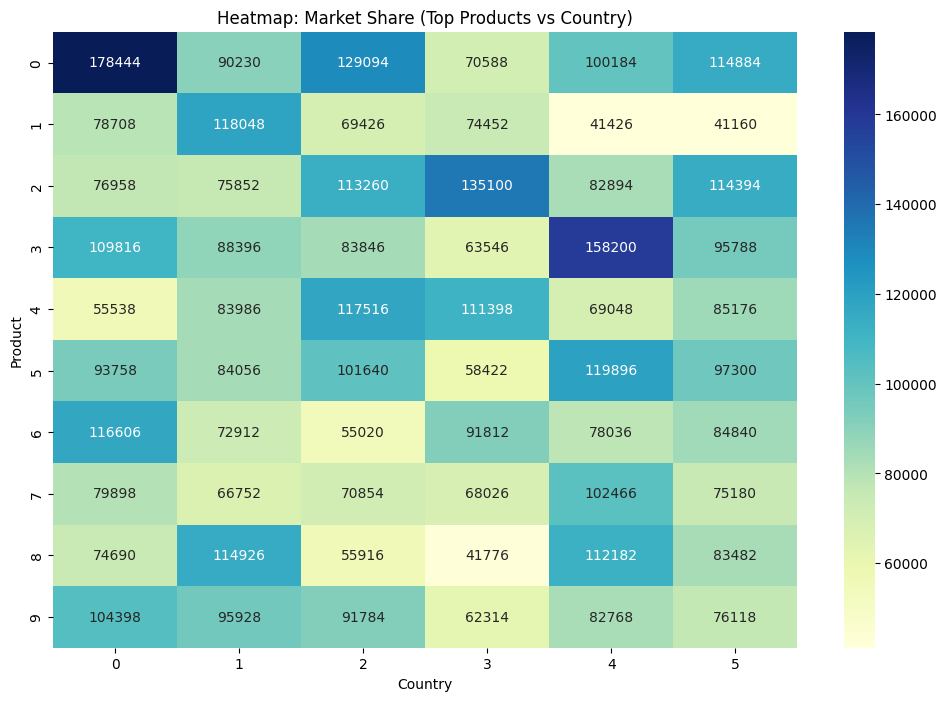

In [26]:
pivot = df.pivot_table(index='Product', columns='Country', values='Amount', aggfunc='sum').fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot.head(10), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Market Share (Top Products vs Country)')
plt.show()